# Notebook to plot EEL sections

*Add description of the project here*

### Import libraries

In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append(r'../') # Add this line at the beginner of each notebook to be able to load local functions 
import src.features.RT_functions as rtf
import src.features.RT_data as rtd
import src.features.matfile_functions as matlab_fct
import src.features.RT_transport as rtt
import src.features.RT_EOF_functions as rt_eof
import src.set_paths as sps
import src.RT_parameters as rtp
import src.features.RT_visualise as rtv

C:\Users\sa07kb\Projects\Rockall_Trough_Transports\notebooks\..\src\features\RT_transport.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from shapely.geometry import Polygon
#plt.style.use('dark_background')

%matplotlib inline


#### Variables

In [3]:
pathdir = sps.one_drive_data_dir/'data_RT_EEL_cruises/EEL_LOIC/csv_ctdgrid'
colsec = 'royalblue'
colvec = 'salmon'
colellipse = 'limegreen'

## 1. Load and Prep. data

In [4]:
# Rockall Trough mooring location
ds_RT_loc=rtd.load_RT_loc()

### 1.1 Load data into DataFrame

In [5]:
file4 = pathdir/'EELCTDandLADCP_3Dfield.csv'
dflad = pd.read_csv(file4,sep=',', index_col=None, 
                     header=0).drop(columns=['Vladcpalong'])


#### 1.1.1 Sort data format and variable name

In [6]:
dflad=dflad.round({'PMTP': 4, 'PSAL': 3, 'Sigma0': 3, 'Vrel': 3, 'Vladcp': 3, 'Vabs': 3})
dflad['Refdist']=dflad['Refdist'].apply(int)
dflad

,CruiseID,Year,Staname,Refdist,Depth,PTMP,PSAL,Sigma0,Vrel,Vladcp,Vabs
0,d22396,1996,14G,1180,25,13.111862,35.194,26.521,0.071,-0.013,0.055
1,d22396,1996,14G,1180,35,13.084566,35.192,26.525,0.070,0.006,0.055
2,d22396,1996,14G,1180,45,12.935832,35.184,26.547,0.071,0.011,0.055
3,d22396,1996,14G,1180,55,12.398809,35.189,26.655,0.070,0.031,0.054
4,d22396,1996,14G,1180,65,11.861810,35.195,26.764,0.064,0.067,0.048
...,...,...,...,...,...,...,...,...,...,...,...
57865,dy078,2017,IB22S,13,65,7.941110,35.064,27.333,-0.053,0.014,-0.005
57866,dy078,2017,IB22S,13,75,7.915402,35.068,27.340,-0.052,-0.021,-0.004
57867,dy078,2017,IB22S,13,85,7.891565,35.074,27.349,-0.052,-0.021,-0.004
57868,dy078,2017,IB22S,13,95,7.856688,35.077,27.356,-0.051,-0.034,-0.004


In [7]:
df3D = dflad.rename(columns={"Refdist": "refdist","Year": "year","Depth": "depth"}).set_index(['refdist','year','depth']).round(3).sort_values(['refdist','year','depth']).drop(columns=['CruiseID','Staname'])
df3D=df3D.rename(columns={"PTMP": "ptmp", "PSAL": "psal", "Sigma0": "sigma0"})
df3D

ptmp    psal  sigma0   Vrel  Vladcp   Vabs
refdist year depth                                             
13      2005 15     8.815  35.020  27.163 -0.005   0.107  0.065
             25     8.827  35.041  27.178 -0.000   0.101  0.070
             35     8.783  35.073  27.210  0.003   0.086  0.073
             45     8.736  35.080  27.222  0.006   0.068  0.076
             55     8.733  35.098  27.237  0.008   0.055  0.078
...                   ...     ...     ...    ...     ...    ...
1242    2017 75     9.571  35.155  27.146  0.011   0.130  0.140
             85     9.472  35.173  27.177  0.008   0.135  0.137
             95     9.465  35.221  27.215  0.005   0.129  0.134
             105    9.538  35.264  27.237  0.002   0.106  0.131
             115    9.532  35.273  27.245 -0.000   0.087  0.129

[57870 rows x 6 columns]

#### 1.1.2 Import additional metadata

In [8]:
# Location of EEL stations
file3 = pathdir/'EELCTDandLADCP_refpos.csv'
dfloc = pd.read_csv(file3,sep=',', index_col=None, 
                     header=0)
dfloc['Refdist'] = dfloc['Refdist'].round(decimals=1)

# Sorted according to distance:
dfs = dfloc.sort_values('Refdist', ascending=True)
print(dfs)

   Staname  Refdist  LonSta  LatSta  DepthSta
68   IB23S      0.0 -20.215  63.317       120
67   IB22S     13.4 -20.067  63.216       670
66   IB21S     25.4 -19.916  63.133      1030
65   IB20S     55.6 -19.551  62.917      1400
64   IB19S     84.0 -19.668  62.667      1670
..     ...      ...     ...     ...       ...
4       5G   1277.5  -6.600  56.733        80
3       4G   1286.6  -6.450  56.733       115
2       3G   1292.4  -6.367  56.708        70
1       2G   1298.2  -6.283  56.683        30
0       1G   1307.6  -6.133  56.667       190

[69 rows x 5 columns]


## 1.2 Convert 3D dataframe into Xarray DataSet

In [9]:
da0 = df3D.to_xarray()
print(da0)

<xarray.Dataset> Size: 11MB
Dimensions:  (refdist: 59, year: 15, depth: 269)
Coordinates:
  * refdist  (refdist) int64 472B 13 25 55 84 122 ... 1180 1191 1222 1232 1242
  * year     (year) int64 120B 1996 1997 1998 1999 2000 ... 2014 2015 2016 2017
  * depth    (depth) int64 2kB 5 15 25 35 45 55 ... 2645 2655 2665 2675 2685
Data variables:
    ptmp     (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan
    psal     (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan
    sigma0   (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan
    Vrel     (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan
    Vladcp   (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan
    Vabs     (refdist, year, depth) float64 2MB nan nan nan nan ... nan nan nan


#### 1.2.1 Add additional Variables from metadatafile (Lat,Lon, Station Name, Cruise ID)

In [10]:
# Get position metadata
dfloc = pd.read_csv(pathdir/'EELCTDandLADCP_refpos.csv',sep=',', index_col=None, 
                     header=0)
# Make sure the station name are sorted by their distance along the section
sdfloc = dfloc.rename(columns={"Refdist": "refdist"}).sort_values('refdist', ascending=True)
sdfloc['refdist']=sdfloc['refdist'].apply(int)
sdfloc=sdfloc.set_index('refdist')

daloc = sdfloc.to_xarray()
print(daloc)

<xarray.Dataset> Size: 3kB
Dimensions:   (refdist: 69)
Coordinates:
  * refdist   (refdist) int64 552B 0 13 25 55 84 ... 1277 1286 1292 1298 1307
Data variables:
    Staname   (refdist) object 552B 'IB23S' 'IB22S' 'IB21S' ... '3G' '2G' '1G'
    LonSta    (refdist) float64 552B -20.21 -20.07 -19.92 ... -6.283 -6.133
    LatSta    (refdist) float64 552B 63.32 63.22 63.13 ... 56.71 56.68 56.67
    DepthSta  (refdist) int64 552B 120 670 1030 1400 1670 ... 80 115 70 30 190


In [11]:
# Get cruise (time) metadata
dfdate = pd.read_csv(pathdir/'EELCTDandLADCP_refdate.csv',sep=',', index_col=None, 
                     header=0).rename(columns={"Year": "year"}).set_index('year')
dadate = dfdate.to_xarray()
print(dadate)

<xarray.Dataset> Size: 408B
Dimensions:   (year: 17)
Coordinates:
  * year      (year) int64 136B 1996 1997 1998 1999 2000 ... 2014 2015 2016 2017
Data variables:
    CruiseID  (year) object 136B 'd22396' 'd23097' 'd23398' ... 'dy052' 'dy078'
    Month     (year) int64 136B 10 9 5 9 2 2 10 10 8 6 5 5 5 7 6 6 5


#### 1.2.2 Merge metadata into main Dataset 

In [12]:
da=xr.merge([da0, daloc,dadate],
           join='outer')
print(da)

<xarray.Dataset> Size: 15MB
Dimensions:   (refdist: 69, year: 17, depth: 269)
Coordinates:
  * refdist   (refdist) int64 552B 0 13 25 55 84 ... 1277 1286 1292 1298 1307
  * year      (year) int64 136B 1996 1997 1998 1999 2000 ... 2014 2015 2016 2017
  * depth     (depth) int64 2kB 5 15 25 35 45 55 ... 2645 2655 2665 2675 2685
Data variables:
    ptmp      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    psal      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    sigma0    (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vrel      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vladcp    (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vabs      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Staname   (refdist) object 552B 'IB23S' 'IB22S' 'IB21S' ... '3G' '2G' '1G'
    LonSta    (refdist) float64 552B -20.21 -20.07 -19.92 ... -6.283 -6.133
    LatSta    (

#### 1.2.3 Move variables into coordinates

In [13]:
da.coords['lon'] = ('refdist', da.LonSta.data)
da.coords['lat'] = ('refdist', da.LatSta.data)
da.coords['Staname'] = ('refdist', da.Staname.data)
da = da.drop_vars(['LonSta','LatSta'])
display(da)

<xarray.Dataset> Size: 15MB
Dimensions:   (refdist: 69, year: 17, depth: 269)
Coordinates:
  * refdist   (refdist) int64 552B 0 13 25 55 84 ... 1277 1286 1292 1298 1307
  * year      (year) int64 136B 1996 1997 1998 1999 2000 ... 2014 2015 2016 2017
  * depth     (depth) int64 2kB 5 15 25 35 45 55 ... 2645 2655 2665 2675 2685
    Staname   (refdist) object 552B 'IB23S' 'IB22S' 'IB21S' ... '3G' '2G' '1G'
    lon       (refdist) float64 552B -20.21 -20.07 -19.92 ... -6.283 -6.133
    lat       (refdist) float64 552B 63.32 63.22 63.13 ... 56.71 56.68 56.67
Data variables:
    ptmp      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    psal      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    sigma0    (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vrel      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vladcp    (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    Vabs      (refdist, year, depth) float64 3MB nan nan nan nan ... nan nan nan
    DepthSta  (refdist) int64 552B 120 670 1030 1400 1670 ... 80 115 70 30 190
    CruiseID  (year) object 136B 'd22396' 'd23097' 'd23398' ... 'dy052' 'dy078'
    Month     (year) int64 136B 10 9 5 9 2 2 10 10 8 6 5 5 5 7 6 6 5

In [14]:
# select only RT section
RT_west = da.swap_dims({'refdist':'Staname'}).sel(Staname='IB1').refdist
RT_east = da.swap_dims({'refdist':'Staname'}).sel(Staname='S').refdist
da = da.sel(refdist=slice(RT_west,RT_east))
RT_west = da.swap_dims({'refdist':'lon'}).sel(
    lon=ds_RT_loc.lon_RTWS,method='nearest').refdist
RT_east = da.swap_dims({'refdist':'lon'}).sel(
    lon=ds_RT_loc.lon_RTES,method='nearest').refdist
da = da.sel(refdist=slice(RT_west,RT_east))

In [15]:
# select only year where all stations in RT were covered
dim='depth'
mask = da.bfill(dim=dim).notnull()
mask_first_depth = mask.Vladcp.isel(depth=0)
mask_years = mask_first_depth.all(dim='refdist').values
da = da.sel(year=mask_years)

In [17]:
#interpolat upper values by repeating upper values to surface
names = ['ptmp', 'psal', 'sigma0', 'Vrel', 'Vladcp', 'Vabs']
for var in names:
    da[var]=rtf.repeat_upper_values(da[var],dim='depth')
da = rtf.calc_SA_CT_sigma0(da, case='ship')

In [113]:
da

<xarray.Dataset> Size: 3MB
Dimensions:   (lon: 16, year: 11, depth: 269)
Coordinates:
    refdist   (lon) int64 128B 875 883 897 920 944 ... 1057 1080 1098 1105 1111
  * year      (year) int64 88B 1996 1999 2005 2006 2009 ... 2014 2015 2016 2017
  * depth     (depth) int64 2kB 5 15 25 35 45 55 ... 2645 2655 2665 2675 2685
    Staname   (lon) object 128B 'C' 'D' 'E' 'F' 'G' 'H' ... 'N' 'O' 'P' 'Q1' 'Q'
  * lon       (lon) float64 128B -13.0 -12.87 -12.63 ... -9.417 -9.317 -9.217
    lat       (lon) float64 128B 57.55 57.54 57.53 57.51 ... 57.1 57.08 57.05
Data variables:
    ptmp      (lon, year, depth) float64 379kB 12.45 12.45 12.45 ... nan nan nan
    psal      (lon, year, depth) float64 379kB 35.19 35.19 35.19 ... nan nan nan
    sigma0    (lon, year, depth) float64 379kB 26.65 26.65 26.65 ... nan nan nan
    Vrel      (lon, year, depth) float64 379kB 0.043 0.043 0.043 ... nan nan nan
    Vladcp    (lon, year, depth) float64 379kB -0.082 -0.082 -0.082 ... nan nan
    Vabs      (lon, year, depth) float64 379kB 0.077 0.077 0.077 ... nan nan nan
    DepthSta  (lon) int64 128B 330 1000 1650 1800 1800 ... 1900 1400 800 500
    CruiseID  (year) object 88B 'd22396' 'd24299' 'cd17605' ... 'dy052' 'dy078'
    Month     (year) int64 88B 10 9 10 10 6 5 5 7 6 6 5
    PRES      (depth, lon) float64 34kB 5.047 5.047 ... 2.727e+03 2.727e+03
    SA        (lon, year, depth) float64 379kB 35.36 35.36 35.36 ... nan nan nan
    CT        (lon, year, depth) float64 379kB 12.44 12.44 12.44 ... nan nan nan

#### 1.2.4 Visual inspection of the data

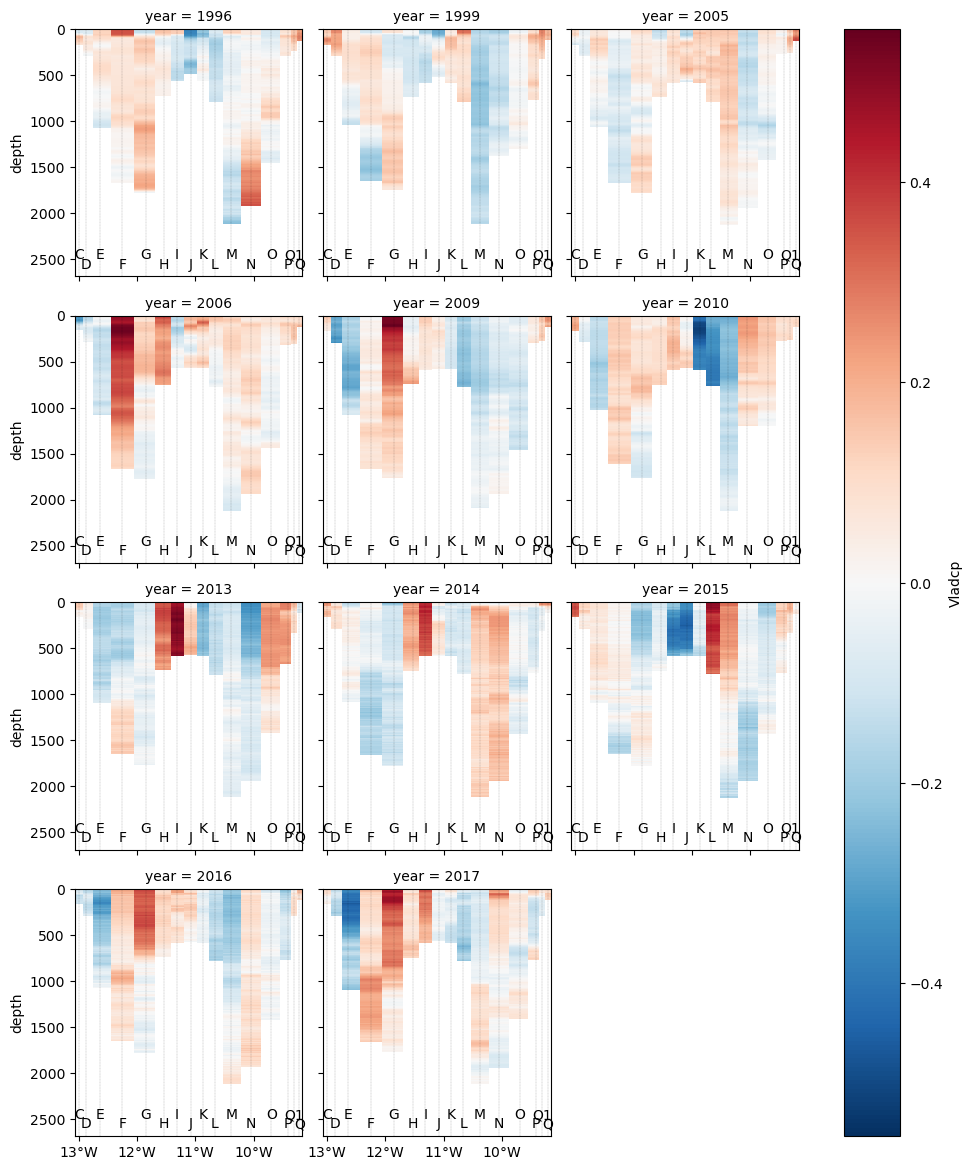

In [37]:
test = da.Vladcp
g = test.plot(x='lon',y='depth',col='year',col_wrap=3, yincrease=False)

for ax in g.axs.flat:
    rtv.axis_lat_lon_formatter(ax,'xlon')
    for i,val in enumerate(test.lon):
    
        ax.axvline(val,linewidth=.2,color='k', ls=':')

        if i % 2 == 0:
            y_text = 2500
        else:
            y_text = 2500 + 100
        
        ax.text(val,y_text,da.Staname[i].values,
               ha='center')

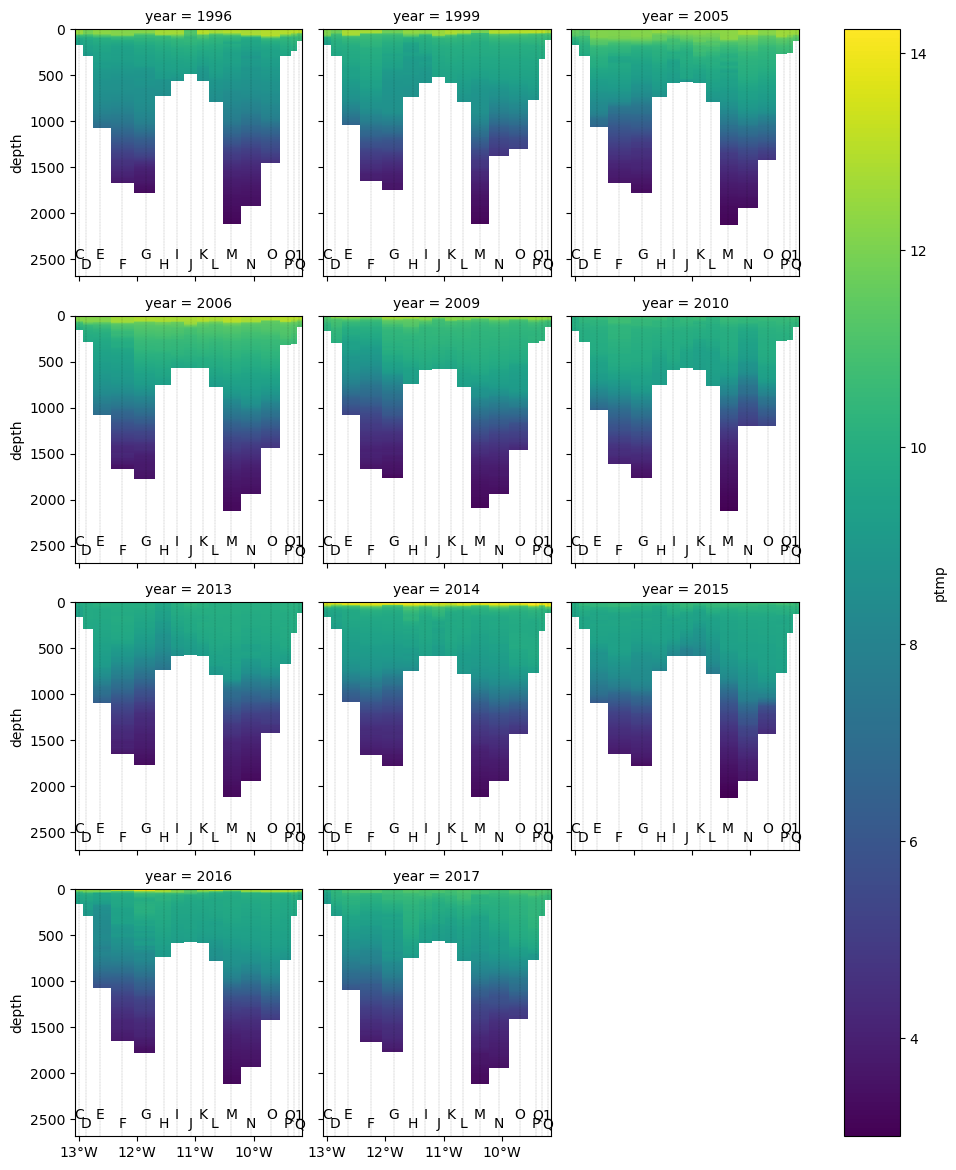

In [19]:
g = da.ptmp.plot(x='lon',y='depth',col='year',col_wrap=3, yincrease=False)

for ax in g.axs.flat:
    rtv.axis_lat_lon_formatter(ax,'xlon')
    for i,val in enumerate(da.lon):
    
        ax.axvline(val,linewidth=.2,color='k', ls=':')

        if i % 2 == 0:
            y_text = 2500
        else:
            y_text = 2500 + 100
        
        ax.text(val,y_text,da.Staname[i].values,
               ha='center')

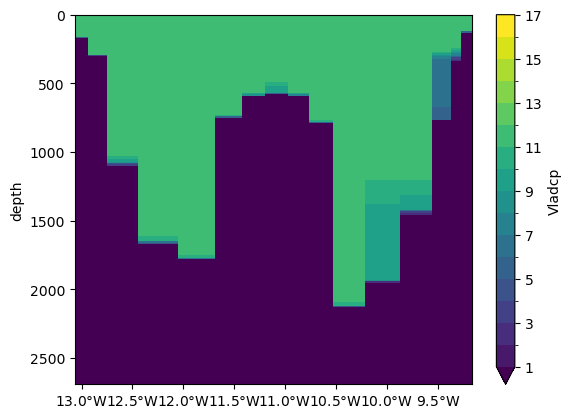

In [20]:
levs = len(da.year)
g = da.Vladcp.count(dim='year').plot(x='lon',y='depth',
                                     vmin=1,vmax=17,
                                     levels=17,
                                     yincrease=False)
rtv.axis_lat_lon_formatter(g.axes,'xlon')

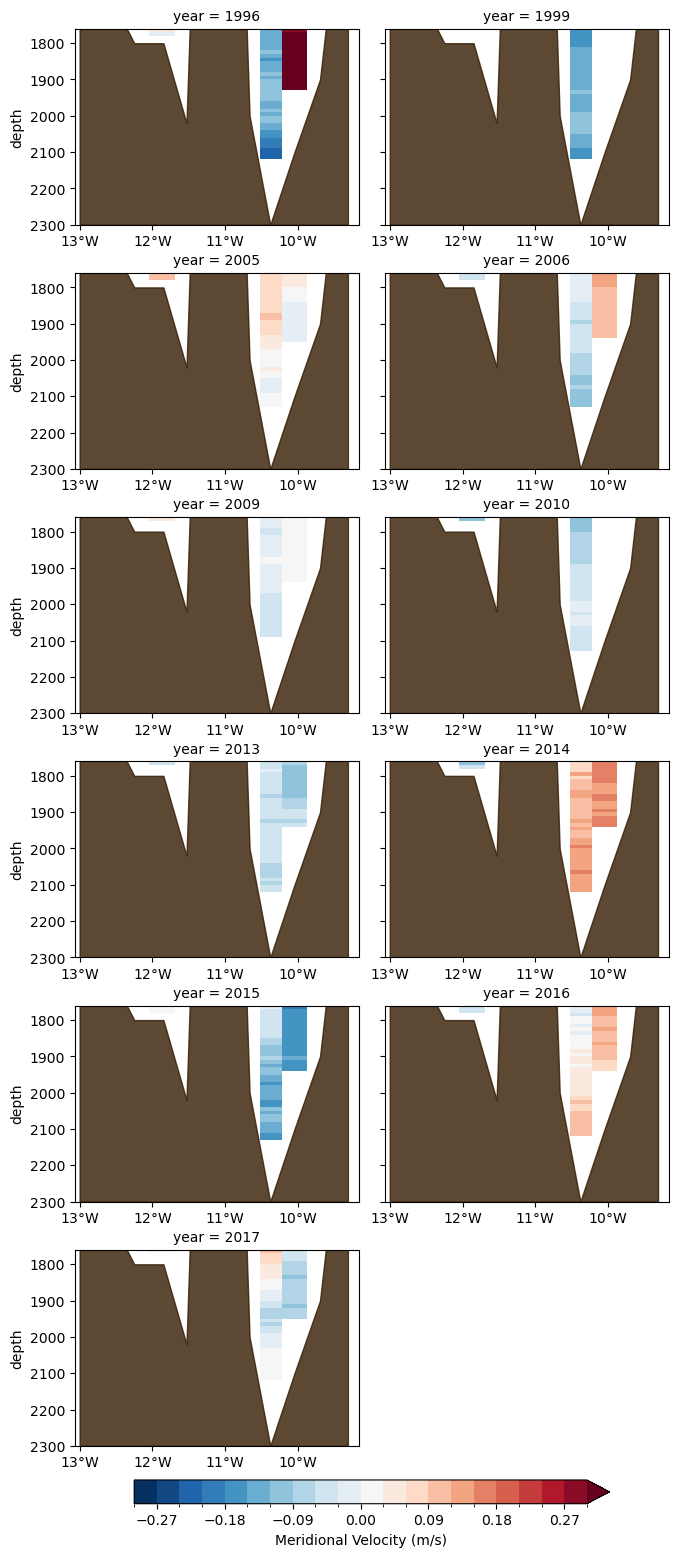

In [21]:
v_lo_1760 = da.Vladcp.sel(depth=slice(1760,2300))

df_indexed  = dfs.set_index('Refdist')
da_depthsta = df_indexed.to_xarray()
da_depthsta = da_depthsta.assign_coords(lon=da_depthsta['LonSta'])
da_depthsta = da_depthsta.sel(Refdist=slice(
            v_lo_1760.refdist.min(),v_lo_1760.refdist.max())
               )
da_depthsta


kwargs = {"cmap": "RdBu_r", "vmin": -.3, "vmax": .3,"levels":21,
          "cbar_kwargs": {"label": "Meridional Velocity (m/s)",
                         'orientation': 'horizontal',
                            'pad': 0.02,
                            'shrink': 0.8 }}
levs = len(v_lo_1760)
g = v_lo_1760.sel(year=slice(None,None)
                 ).plot(x='lon',y='depth',col='year',col_wrap=2,
                   yincrease=False,sharex=False,
                  **kwargs)
for ax in g.axs.flat:
    rtv.axis_lat_lon_formatter(ax,'xlon')
    ax.fill_between(da_depthsta['lon'], da_depthsta['DepthSta'], 
                    2300, color="#331a00", alpha=0.8)

In [22]:
def calc_polygon(x,z):
    coords = np.column_stack((x,z))
    polygon = Polygon(coords)
    return polygon


z1 = np.array([1760, 2000, 2300, 2100, 1900, 1760 ])
x1 = np.array([990.9, 1005. , 1017.5, 1036.1, 1057.4, 1080.5])
z2 =  np.array([1760, 2020,  1760])
x2 = np.array([944.8,  963.8, 976.8])

polygon1 = calc_polygon(x1*1e3,z1)
polygon2 = calc_polygon(x2*1e3,z2)

print(f'5mm current translate to an error of {(polygon1.area+polygon2.area)*0.005*1e-6} Sv')

5mm current translate to an error of 0.1281999999999999 Sv


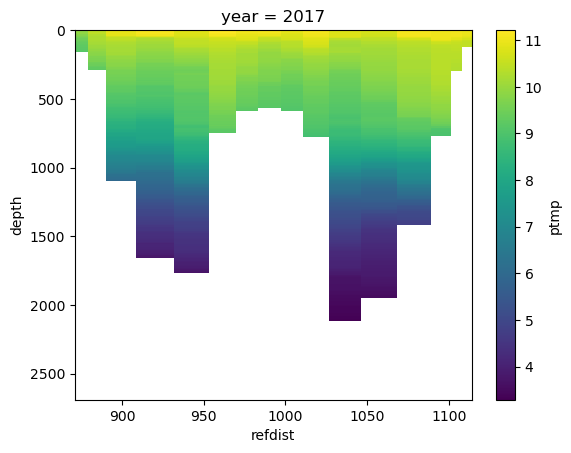

In [23]:
da.ptmp.sel(year=2017).plot(y='depth', yincrease=False)

\
Plot evolution of Velocity profile at station E

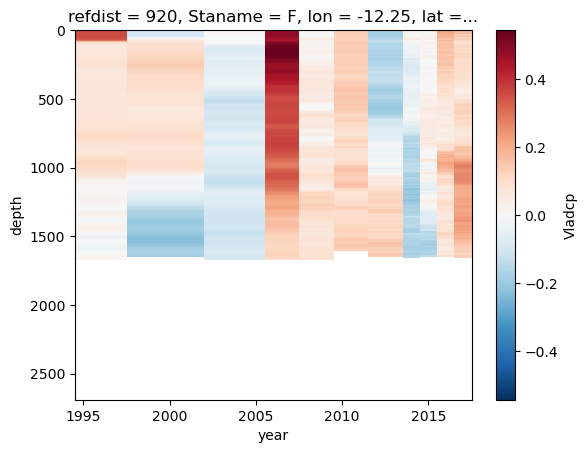

In [38]:
# Extra Refdist value associated with Station E and F
staE = da.refdist.values[da.Staname.values=='E'][0]
staF = da.refdist.values[da.Staname.values=='F'][0]

# Plot 
da.Vladcp.sel(refdist=staF,
              year=slice(None,'2017')
             ).plot(y='depth', yincrease=False)

In [26]:
Vladcpmean = da.Vladcp.mean('year')
Vladcpstd = da.Vladcp.std(dim='year')

\
Plot with data with min and max values

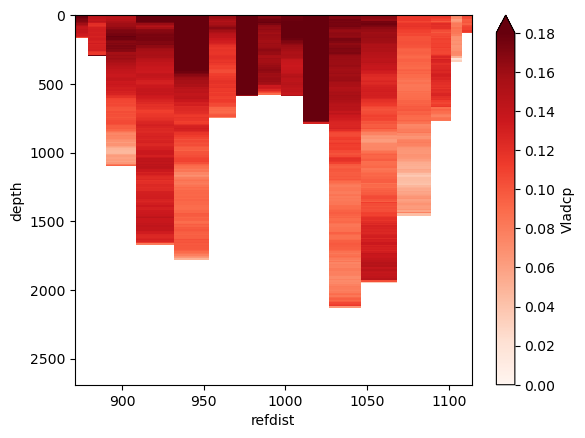

In [27]:
Vladcpstd.plot(y='depth', yincrease=False, vmin=0, vmax=0.18, cmap=plt.cm.Reds)

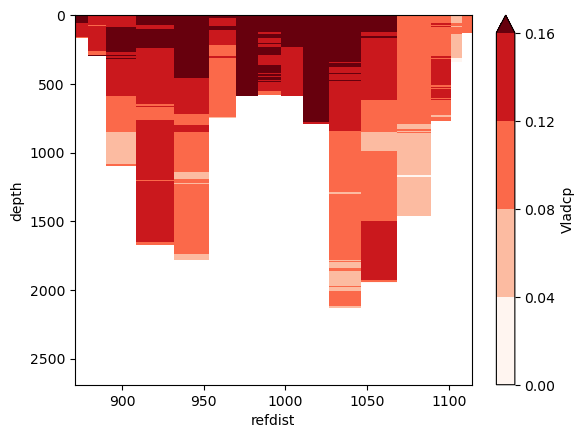

In [28]:
Vladcpstd.plot(y='depth', yincrease=False, levels=np.arange(0, 0.18, 0.04), cmap=plt.cm.Reds)

## 2. Contour plot

Create list of namedtuples for variable to plot on the figure with several subpanels:
The rows of the figure correspond to variable (Temperature, Salinity, Density, Velocity) while the columns correspond to the mean and standard deviation


In [29]:
import collections
fields = [
    'xarray_var',
    'short_name',
    'var_type',
    'contourf_lvls',
    'contour_lvls',    
    'cmap',
    'long_name',
    'cbar_title',
    ]
Datatoplot = collections.namedtuple('Datatoplot',fields,defaults=(None,) * len(fields))

In [30]:
Datatoplot?

Init signature:
Datatoplot(
    xarray_var=None,
    short_name=None,
    var_type=None,
    contourf_lvls=None,
    contour_lvls=None,
    cmap=None,
    long_name=None,
    cbar_title=None,
)
Docstring:      Datatoplot(xarray_var, short_name, var_type, contourf_lvls, contour_lvls, cmap, long_name, cbar_title)
Type:           type
Subclasses:     

##### Definitions of the list of variables to plot with plotting options

In [31]:

ptmp_mean = Datatoplot(xarray_var='ptmp', short_name='Mean Pot. Temp.', var_type='mean', 
                      contourf_lvls= np.arange(3, 11, 1),cmap='plasma', 
                      long_name = 'Mean Potential Temperature', cbar_title =r'$^\circ$C')

ptmp_std = Datatoplot(xarray_var='ptmp', short_name='Std Pot. Temp.', var_type='std', 
                      contourf_lvls= np.arange(0, 1.2, 0.2),cmap='OrRd', 
                      long_name = 'Std Potential Temperature', cbar_title =r'$^\circ$C')

psal_mean = Datatoplot(xarray_var='psal', short_name='Mean Sal.', var_type='mean', 
                      contourf_lvls= np.arange(34.9, 35.45, 0.05), cmap='viridis', 
                      long_name = 'Mean Salinity', cbar_title =' ')

psal_std = Datatoplot(xarray_var='psal', short_name='Std Sal.', var_type='std', 
                      contourf_lvls= np.arange(0, 0.12, 0.02),cmap='OrRd', 
                      long_name = 'Std Salinity', cbar_title =' ')

sigma0_mean = Datatoplot(xarray_var='sigma0', short_name='Mean Pot. Dens. Ano.', var_type='mean', 
                      contourf_lvls= np.arange(27.2, 27.9, 0.1), cmap='cividis_r', 
                      long_name = 'Mean Potential Density Anomaly', cbar_title ='kg.m$^{-3}$')

sigma0_std = Datatoplot(xarray_var='sigma0', short_name='Std Pot. Dens. Ano.', var_type='std', 
                      contourf_lvls= np.arange(0, 0.12, 0.02),cmap='OrRd', 
                      long_name = 'Std Potential Density Anomaly', cbar_title ='kg.m$^{-3}$')

ladcp_mean = Datatoplot(xarray_var='Vladcp', short_name='Mean LADCP Vel.', var_type='mean', 
                      contourf_lvls= np.arange(-16, 20, 4)/100, cmap='coolwarm', 
                      long_name = 'Mean cross-section velocity from LADCP', cbar_title ='m.s$^{-1}$')

ladcp_std = Datatoplot(xarray_var='Vladcp', short_name='Std LADCP Vel.', var_type='std', 
                      contourf_lvls= np.arange(0, 18, 4)/100, cmap='OrRd', 
                      long_name = 'Std cross-section velocity from LADCP', cbar_title ='m.s$^{-1}$')

# Create a list of namedtuples
varstoplot=((ptmp_mean,ptmp_std),
              (psal_mean,psal_std),
              (sigma0_mean,sigma0_std),
              (ladcp_mean,ladcp_std),            
           )

Definition of a class to display a "pretty" formatting of the namedtuples (from [stackoverflow post](https://stackoverflow.com/a/43823671/13890678)):

In [32]:
from io import StringIO
import pprint

class MyPrettyPrinter(pprint.PrettyPrinter):
    def format_namedtuple(self, object, stream, indent, allowance, context, level):
        # Code almost equal to _format_dict, see pprint code
        write = stream.write
        write(object.__class__.__name__ + '(')
        object_dict = object._asdict()
        length = len(object_dict)
        if length:
            # We first try to print inline, and if it is too large then we print it on multiple lines
            inline_stream = StringIO()
            self.format_namedtuple_items(object_dict.items(), inline_stream, indent, allowance + 1, context, level, inline=True)
            max_width = self._width - indent - allowance
            if len(inline_stream.getvalue()) > max_width:
                self.format_namedtuple_items(object_dict.items(), stream, indent, allowance + 1, context, level, inline=False)
            else:
                stream.write(inline_stream.getvalue())
        write(')')

    def format_namedtuple_items(self, items, stream, indent, allowance, context, level, inline=False):
        # Code almost equal to _format_dict_items, see pprint code
        indent += self._indent_per_level
        write = stream.write
        last_index = len(items) - 1
        if inline:
            delimnl = ', '
        else:
            delimnl = ',\n' + ' ' * indent
            write('\n' + ' ' * indent)
        for i, (key, ent) in enumerate(items):
            last = i == last_index
            write(key + '=')
            self._format(ent, stream, indent + len(key) + 2,
                         allowance if last else 1,
                         context, level)
            if not last:
                write(delimnl)

    def _format(self, object, stream, indent, allowance, context, level):
        # We dynamically add the types of our namedtuple and namedtuple like 
        # classes to the _dispatch object of pprint that maps classes to
        # formatting methods
        # We use a simple criteria (_asdict method) that allows us to use the
        # same formatting on other classes but a more precise one is possible
        if hasattr(object, '_asdict') and type(object).__repr__ not in self._dispatch:
            self._dispatch[type(object).__repr__] = MyPrettyPrinter.format_namedtuple
        super()._format(object, stream, indent, allowance, context, level)

In [33]:
pp = MyPrettyPrinter(indent=2, depth=4)
pp.pprint(varstoplot)

( ( Datatoplot(
      xarray_var='ptmp',
      short_name='Mean Pot. Temp.',
      var_type='mean',
      contourf_lvls=array([ 3,  4,  5,  6,  7,  8,  9, 10]),
      contour_lvls=None,
      cmap='plasma',
      long_name='Mean Potential Temperature',
      cbar_title='$^\\circ$C'),
    Datatoplot(
      xarray_var='ptmp',
      short_name='Std Pot. Temp.',
      var_type='std',
      contourf_lvls=array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
      contour_lvls=None,
      cmap='OrRd',
      long_name='Std Potential Temperature',
      cbar_title='$^\\circ$C')),
  ( Datatoplot(
      xarray_var='psal',
      short_name='Mean Sal.',
      var_type='mean',
      contourf_lvls=array([34.9 , 34.95, 35.  , 35.05, 35.1 , 35.15, 35.2 , 35.25, 35.3 ,
       35.35, 35.4 , 35.45]),
      contour_lvls=None,
      cmap='viridis',
      long_name='Mean Salinity',
      cbar_title=' '),
    Datatoplot(
      xarray_var='psal',
      short_name='Std Sal.',
      var_type='std',
      contourf_lvls=array([

### 2.1 with matplotlib

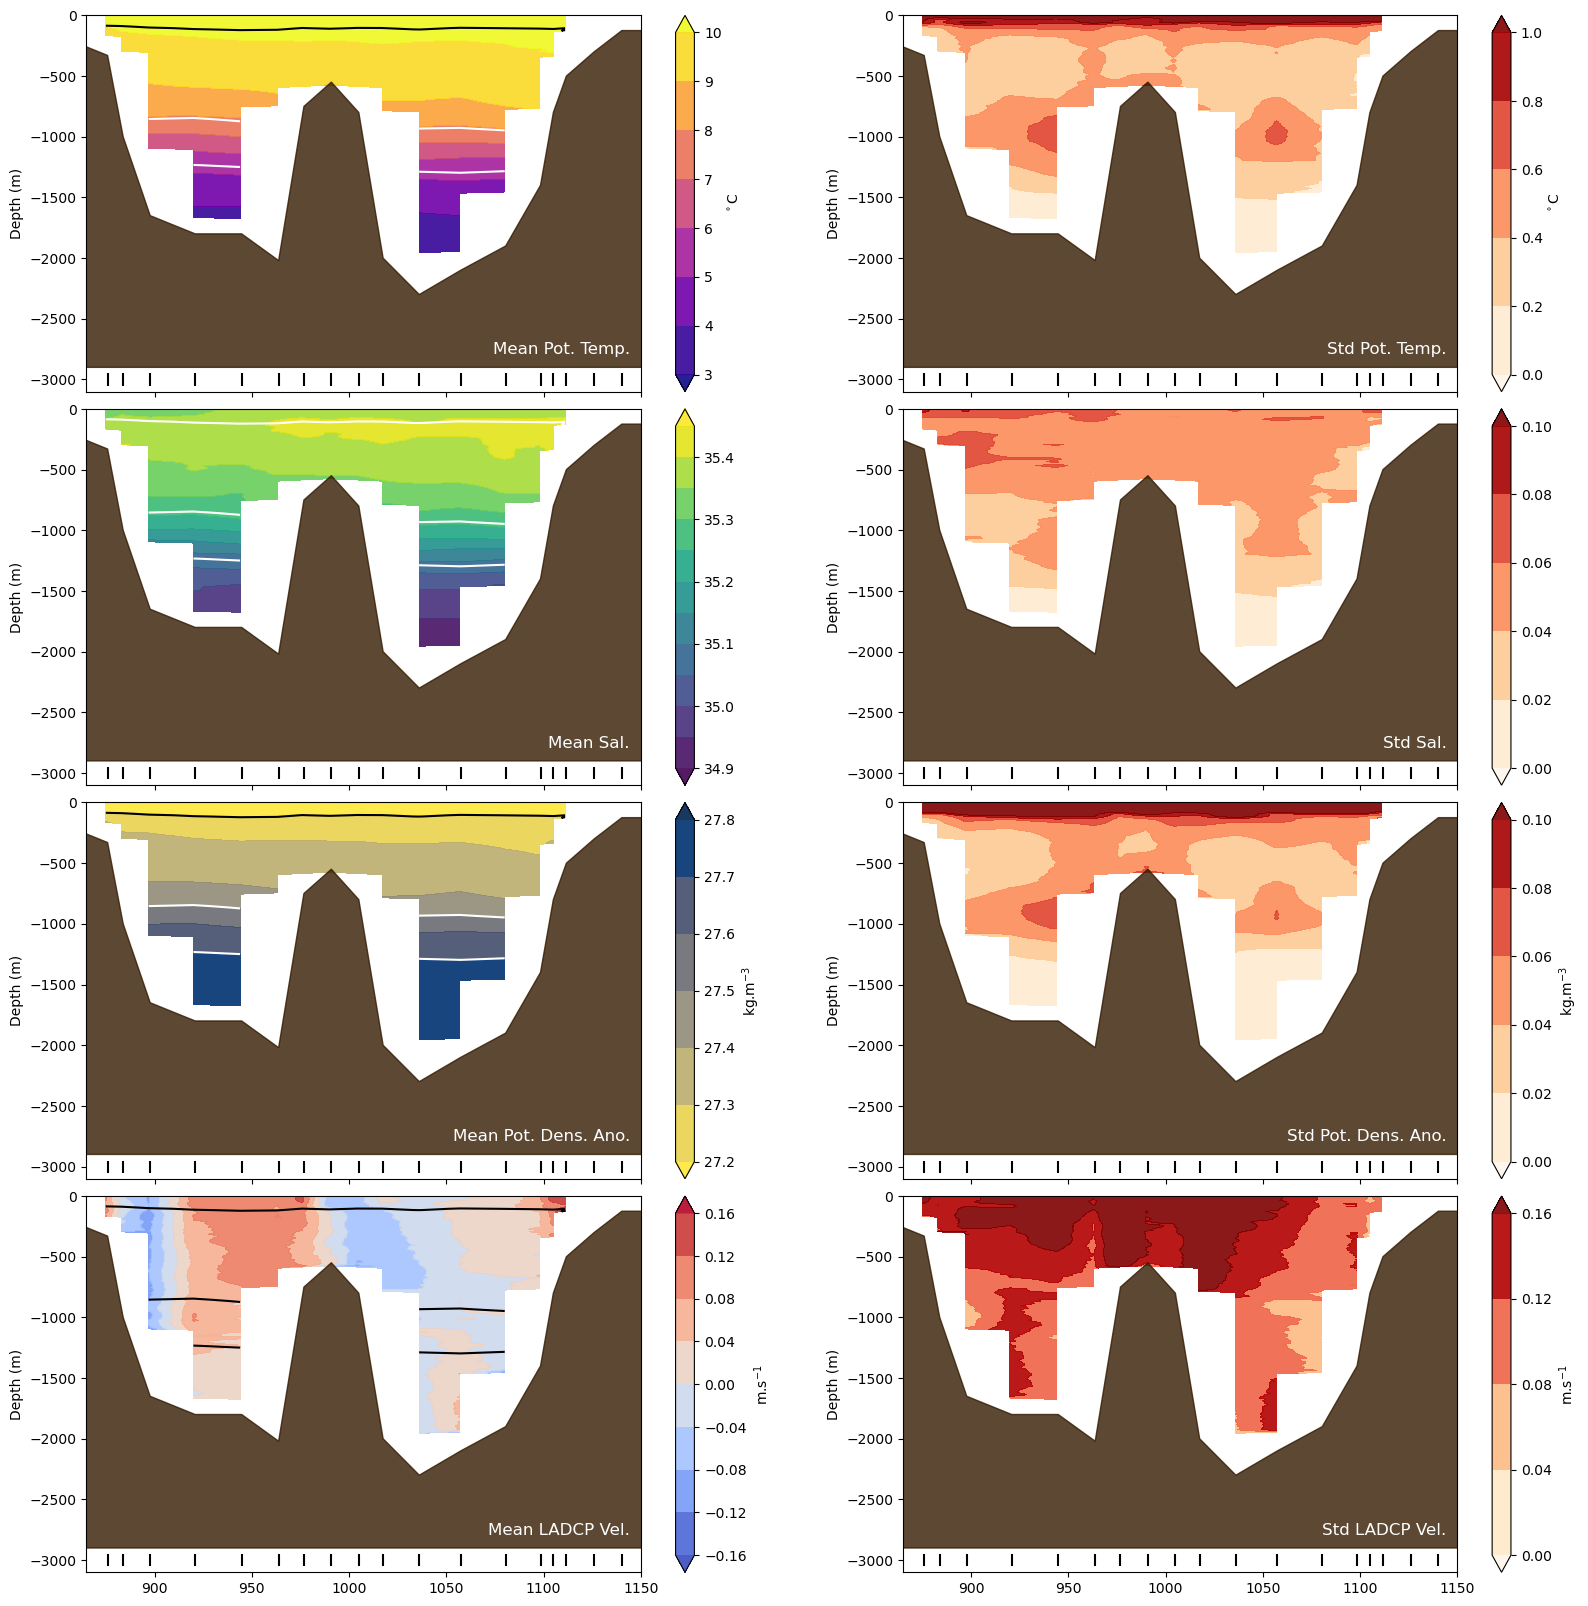

In [41]:
#plt.rcParams.update({'font.size': 10})
    
# Create the figure
## fig, axs = plt.subplots(4, 2, figsize=(12, 12), constrained_layout=True)
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(16, 16))

for row in [0,1,2,3]:
    for col in [0,1]:

            data = varstoplot[row][col]
            if data.var_type == 'mean':
                var = da[data.xarray_var].mean('year')
            elif data.var_type == 'std':
                var = da[data.xarray_var].std('year')   
            else:
                raise ValueError(f"wrong var_type in {data}")

            cf_levels = data.contourf_lvls
            colmap = getattr(plt.cm, data.cmap)
    #         if VarDir['cmap'] == 'cividis':
    #             colmap = colmap[:-1,:]

            pltitle = data.long_name
            plunits = data.cbar_title

            X=da.refdist.values
            Y=da.depth.values
            Z=var.values
            Xi,Yi = np.meshgrid(X, Y, indexing='ij')

            ax = axs[row, col]
    #        ax = axs[col]

            CS = ax.contourf(Xi, -Yi, Z, cf_levels, alpha=0.9, cmap=colmap, extend='both');

            if data.contour_lvls is not None:
                CS2 = ax.contour(CS, levels=data.contour_lvls, colors='k')

            # Plot specific potential density contour indicating of different water masses
            # adapt the line colors according to background colormap
            c_WM = [27.20,27.50,27.70,27.85]
            if data.var_type == 'mean':
                if data.xarray_var == 'psal':
                    colors_list = ['w']
                elif data.xarray_var == 'Vladcp':
                    colors_list = ['k']
                elif data.var_type == 'std':
                    colors_list = ['w'] + ['k'] * (len(c_WM) - 1)
                else:    
                    colors_list = ['k'] + ['w'] * (len(c_WM) - 1)
                CS_WM = ax.contour(Xi, -Yi, da['sigma0'].mean('year'),
                                   levels=c_WM, colors=colors_list )
                
            ax.set_ylabel('Depth (m)')
            ax.set_xlim([np.min(X)-10,1150]) 
            ax.set_ylim([-3100,0])    

            # ax.set_title(pltitle)
            ax.text(0.98, 0.1, data.short_name, 
                    fontsize=12, color ='white',
                    transform=ax.transAxes,
                    horizontalalignment='right',)

            # Make a colorbar for the ContourSet returned by the contourf call.
            cbar = fig.colorbar(CS, ax=ax)
            cbar.ax.set_ylabel(plunits)
            #cbar.ax.set_ylabel('m/s')

            # Add the contour line levels to the colorbar
            if data.contour_lvls is not None:   
                cbar.add_lines(CS2)

            # Add bathymetry (from the nominal depth of the reference EEL stations)
            ax.fill_between(dfs['Refdist'], -dfs['DepthSta'], -2900, color="#331a00", alpha=0.8)

            ax.vlines(dfs['Refdist'], -3050, -2950, colors='k')

            
plt.tight_layout(pad=0.5,w_pad=3)          

# plt.savefig('figures/02_' + 'figure4x2.pdf')      

# Calculate Transports

In [106]:
## grid data
da = da.swap_dims({'refdist':'lon'})
da_u1800 = da.sel(depth=slice(None,1800))
lon_grid = xr.DataArray(np.linspace(ds_RT_loc.lon_RTWS.values,
                               ds_RT_loc.lon_RTES.values,rtp.NX_MB),dims='lon')
da_u1800 = da_u1800.interp(lon=lon_grid,method='linear')
da_u1800['year']=da.year
da_u1800['depth']=da.depth.sel(depth=slice(None,1800))
da_u1800['lat']=da_u1800.lat.interpolate_na('lon',method='nearest',
        fill_value="extrapolate")
da_u1800

<xarray.Dataset> Size: 13MB
Dimensions:   (lon: 100, year: 11, depth: 180)
Coordinates:
    refdist   (lon) float64 800B nan 875.4 877.7 ... 1.108e+03 1.11e+03 nan
  * year      (year) int64 88B 1996 1999 2005 2006 2009 ... 2014 2015 2016 2017
  * depth     (depth) int64 1kB 5 15 25 35 45 55 ... 1755 1765 1775 1785 1795
    lat       (lon) float64 800B 57.55 57.55 57.55 57.54 ... 57.06 57.05 57.05
  * lon       (lon) float64 800B -13.03 -12.99 -12.95 ... -9.27 -9.232 -9.193
    Staname   (lon) object 800B 'C' 'C' 'C' 'D' 'D' ... 'Q1' 'Q1' 'Q1' 'Q' 'Q'
Data variables:
    ptmp      (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    psal      (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    sigma0    (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    Vrel      (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    Vladcp    (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    Vabs      (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    DepthSta  (lon) float64 800B nan 362.7 558.0 753.4 ... 776.7 660.4 544.0 nan
    CruiseID  (year) object 88B 'd22396' 'd24299' 'cd17605' ... 'dy052' 'dy078'
    Month     (year) int64 88B 10 9 10 10 6 5 5 7 6 6 5
    PRES      (depth, lon) float64 144kB nan 5.047 5.047 ... 1.82e+03 nan
    SA        (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan
    CT        (lon, year, depth) float64 2MB nan nan nan nan ... nan nan nan nan

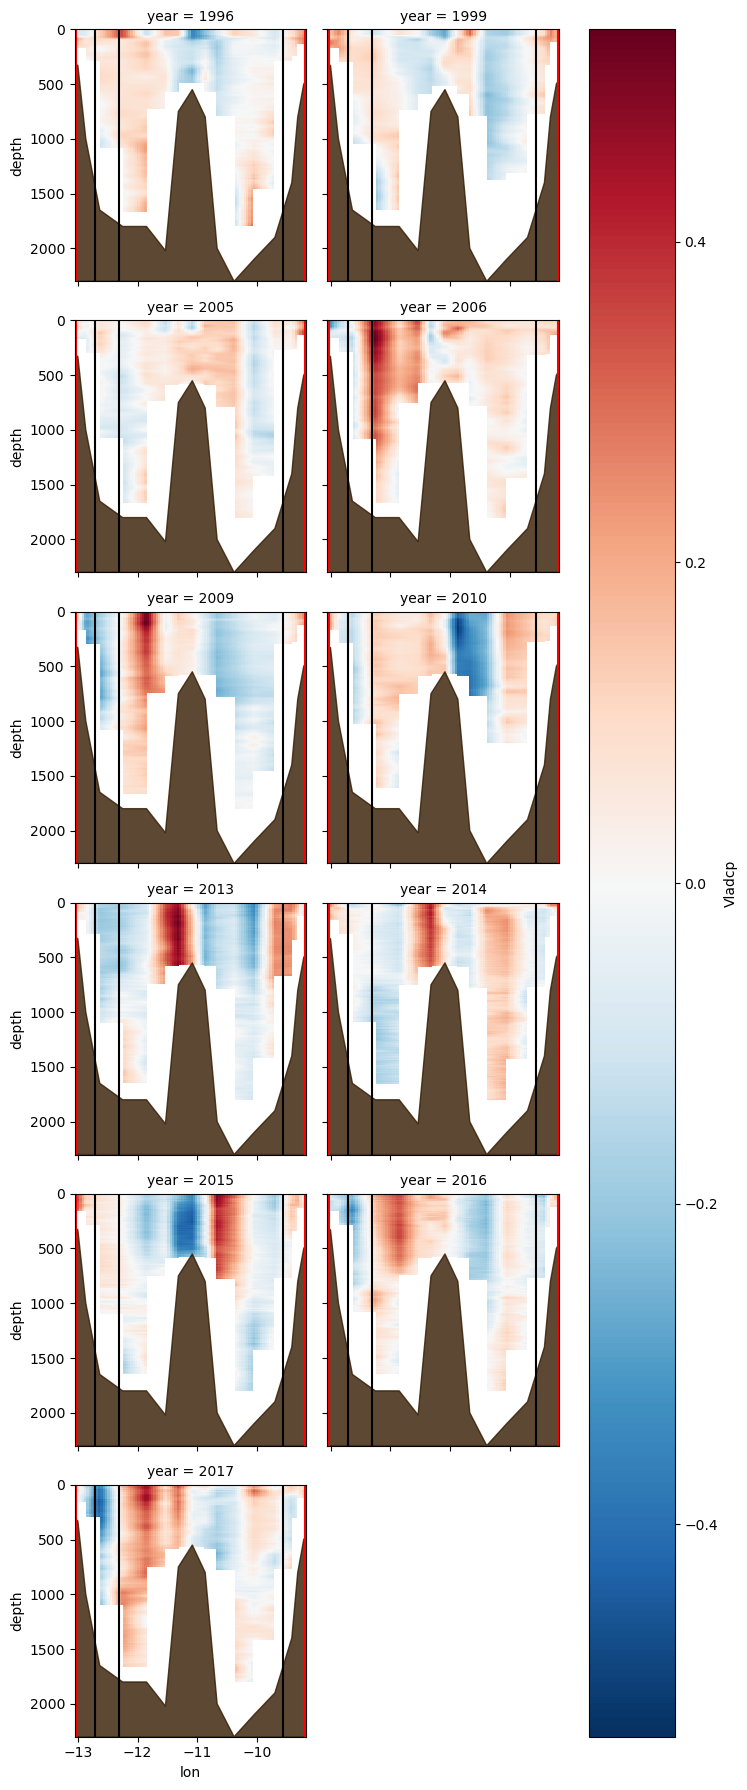

In [88]:
g = da_u1800.Vladcp.plot(x='lon',col='year',col_wrap=2, yincrease=False)
for ax in g.axs.flat:
    ax.axvline(ds_RT_loc.lon_RTES,color='r')
    ax.axvline(ds_RT_loc.lon_RTWS,color='r')
    ax.axvline(ds_RT_loc.lon_RTEB,color='k')
    ax.axvline(ds_RT_loc.lon_RTWB2,color='k')
    ax.axvline(ds_RT_loc.lon_RTWB1,color='k')
    # Add bathymetry (from the nominal depth of the reference EEL stations)
    ax.set_ylim([2300,None])
    ax.fill_between(dfs['LonSta'], dfs['DepthSta'], 2300, color="#331a00", alpha=0.8)

In [97]:
# def calc_transport_VHF(ds,dims,sec_str):
dims = ['lon','depth']
sec_str = 'ship'
ds = da_u1800.rename({'Vladcp':'vcur'})

dx = rtt.get_dx(ds.lon,ds.lat,dim='lon')
dz = rtt.get_dz(ds.vcur.depth)
dz
q = ds.vcur.rename('q')*dx*dz
Q = q.sum(dims)*1e-6
Q.attrs = {'long_name':'Volume Transport','units':'Sv'}

ds_Q,ds_q = rtt.calc_transports(Q,q,ds.CT,ds.SA,dims,sec_str)
ds_Q
# return ds_Q,ds_q

<xarray.Dataset> Size: 440B
Dimensions:  (year: 11)
Coordinates:
  * year     (year) int64 88B 1996 1999 2005 2006 2009 ... 2014 2015 2016 2017
Data variables:
    Q        (year) float64 88B 4.479 -3.358 3.683 20.92 ... -3.501 3.533 8.295
    Qh       (year) float64 88B -0.006602 -0.007854 0.05835 ... 0.01483 0.02939
    Qf       (year) float64 88B 0.009542 0.007579 -0.02502 ... -0.00163 -0.01184
    QS       (year) float64 88B 153.7 -115.8 127.6 723.5 ... -120.5 121.6 285.8
Attributes:
    description:  Volume, heat, freshwater and salt tranport for ship of Rock...

In [112]:
# WW 
CT_WB1 = da.CT.sel(lon=ds_RT_loc.lon_RTWB1,method='nearest'
                        ).sel(depth=slice(None,1600))
# CT_WB1.plot(y='depth')
CT_WB2= da_u1800.CT.sel(lon=ds_RT_loc.lon_RTWB2,method='nearest')
CT_WB1

<xarray.DataArray 'CT' (year: 11, depth: 160)> Size: 14kB
array([[12.25374926, 12.25374801, 12.25374478, ...,         nan,
                nan,         nan],
       [12.75557121, 12.75556992, 12.75556658, ...,         nan,
                nan,         nan],
       [12.07735711, 12.07735588, 12.08232814, ...,         nan,
                nan,         nan],
       ...,
       [10.35093715, 10.35093605, 10.35293143, ...,         nan,
                nan,         nan],
       [12.06120776, 12.06120653, 11.88409635, ...,         nan,
                nan,         nan],
       [10.90741521, 10.90741406, 10.90741108, ...,         nan,
                nan,         nan]], shape=(11, 160))
Coordinates:
    refdist  int64 8B 897
  * year     (year) int64 88B 1996 1999 2005 2006 2009 ... 2014 2015 2016 2017
  * depth    (depth) int64 1kB 5 15 25 35 45 55 ... 1555 1565 1575 1585 1595
    Staname  object 8B 'E'
    lon      float64 8B -12.63
    lat      float64 8B 57.53
Attributes:
    long_name:    Conservative temperature
    description:  conservative temperature TEOS-10
    units:        degC